In [2]:
!pip install -q scikit-fuzzy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.9 MB/s eta 0:00:00a 0:00:01


In [15]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.cluster import KMeans
from sklearn.metrics import jaccard_score
import skfuzzy as fuzz
from scipy.spatial.distance import directed_hausdorff

In [16]:
BASE_PATH = "/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask"

TRAIN_IMG = os.path.join(BASE_PATH, "train/original")
TRAIN_MASK = os.path.join(BASE_PATH, "train/mask")

TEST_IMG = os.path.join(BASE_PATH, "test/original")
TEST_MASK = os.path.join(BASE_PATH, "test/mask")

In [17]:
def load_image_mask_pairs(img_dir, mask_dir):
    images = []
    masks = []
    
    img_files = sorted(os.listdir(img_dir))
    
    for file in tqdm(img_files):
        img_path = os.path.join(img_dir, file)
        mask_path = os.path.join(mask_dir, file.replace('.jpg', '.png'))
        
        if not os.path.exists(mask_path):
            continue
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        mask = cv2.imread(mask_path, 0)
        
        images.append(img)
        masks.append(mask)
        
    return images, masks


test_images, test_masks = load_image_mask_pairs(TEST_IMG, TEST_MASK)

print("Total Test Images Loaded:", len(test_images))

100%|██████████| 159/159 [00:15<00:00, 10.32it/s]

Total Test Images Loaded: 159


In [18]:
def preprocess(img):
    img = cv2.resize(img, (128,128))
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    return lab

def segment_kmeans(img, n_clusters=3):
    lab = preprocess(img)
    pixels = lab.reshape((-1,3)).astype(np.float32)
    
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    labels = kmeans.fit_predict(pixels)
    
    return labels.reshape(128,128), kmeans.cluster_centers_

In [19]:
def segment_fcm(img, n_clusters=3):
    lab = preprocess(img)
    pixels = lab.reshape((-1,3)).astype(np.float64)
    
    data = pixels.T
    
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        data,
        c=n_clusters,
        m=2.0,
        error=0.005,
        maxiter=500
    )
    
    labels = np.argmax(u, axis=0)
    
    return labels.reshape(128,128), cntr

In [20]:
def cluster_to_binary(segmented, centers):
    
    sorted_ids = np.argsort(centers[:,0])
    nucleus_cluster = sorted_ids[0]
    
    return (segmented == nucleus_cluster).astype(np.uint8)

def calculate_all_metrics(gt, pred):

    gt = gt.astype(np.uint8)
    pred = pred.astype(np.uint8)

    TP = np.logical_and(gt==1, pred==1).sum()
    TN = np.logical_and(gt==0, pred==0).sum()
    FP = np.logical_and(gt==0, pred==1).sum()
    FN = np.logical_and(gt==1, pred==0).sum()

    accuracy = (TP+TN)/(TP+TN+FP+FN+1e-8)
    precision = TP/(TP+FP+1e-8)
    recall = TP/(TP+FN+1e-8)
    specificity = TN/(TN+FP+1e-8)

    f1 = 2*(precision*recall)/(precision+recall+1e-8)
    iou = TP/(TP+FP+FN+1e-8)

    pts1 = np.argwhere(gt==1)
    pts2 = np.argwhere(pred==1)

    if len(pts1)==0 or len(pts2)==0:
        hd = 0
    else:
        hd = max(directed_hausdorff(pts1, pts2)[0],
                 directed_hausdorff(pts2, pts1)[0])

    return accuracy, precision, recall, specificity, f1, iou, hd

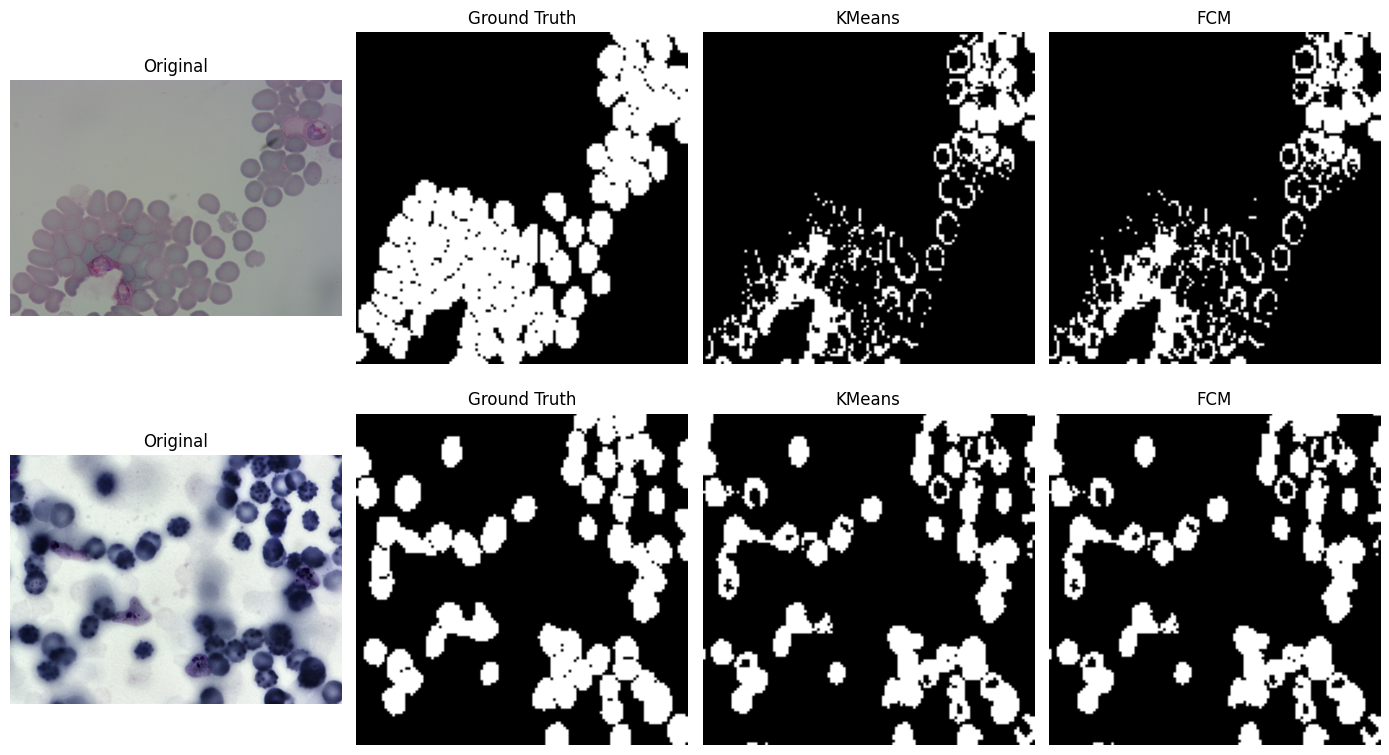

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(14,8))

for i in range(2):
    
    img = test_images[i]
    mask = test_masks[i]
    
    mask = cv2.resize(mask, (128,128))
    mask = (mask>0).astype(np.uint8)
    
    km_seg, km_centers = segment_kmeans(img)
    fm_seg, fm_centers = segment_fcm(img)
    
    km_bin = cluster_to_binary(km_seg, km_centers)
    fm_bin = cluster_to_binary(fm_seg, fm_centers)
    
    axes[i,0].imshow(img)
    axes[i,0].set_title("Original")
    axes[i,0].axis("off")
    
    axes[i,1].imshow(mask, cmap='gray')
    axes[i,1].set_title("Ground Truth")
    axes[i,1].axis("off")
    
    axes[i,2].imshow(km_bin, cmap='gray')
    axes[i,2].set_title("KMeans")
    axes[i,2].axis("off")
    
    axes[i,3].imshow(fm_bin, cmap='gray')
    axes[i,3].set_title("FCM")
    axes[i,3].axis("off")

plt.tight_layout()
plt.show()

In [22]:
kmeans_scores = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'specificity': [],
    'f1_score': [],
    'iou': [],
    'hausdorff': []
}

fcm_scores = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'specificity': [],
    'f1_score': [],
    'iou': [],
    'hausdorff': []
}


for img, mask in tqdm(zip(test_images, test_masks), total=len(test_images)):
    
    mask = cv2.resize(mask, (128,128))
    mask = (mask>0).astype(np.uint8)
    
    km_seg, km_centers = segment_kmeans(img)
    fm_seg, fm_centers = segment_fcm(img)
    
    km_bin = cluster_to_binary(km_seg, km_centers)
    fm_bin = cluster_to_binary(fm_seg, fm_centers)
    
    km_metrics = calculate_all_metrics(mask, km_bin)
    fm_metrics = calculate_all_metrics(mask, fm_bin)
    
    for key, value in zip(kmeans_scores.keys(), km_metrics):
        kmeans_scores[key].append(value)
        
    for key, value in zip(fcm_scores.keys(), fm_metrics):
        fcm_scores[key].append(value)

100%|██████████| 159/159 [01:17<00:00,  2.04it/s]


In [24]:
print("="*60)
print("K-MEANS DATASET AVERAGE RESULTS")
print("="*60)
for key in kmeans_scores:
    print(f"{key:<15}: {np.mean(kmeans_scores[key]):.4f}")

print("\n" + "="*60)
print("FUZZY C-MEANS DATASET AVERAGE RESULTS")
print("="*60)
for key in fcm_scores:
    print(f"{key:<15}: {np.mean(fcm_scores[key]):.4f}")

K-MEANS DATASET AVERAGE RESULTS
accuracy       : 0.8615
precision      : 0.9715
recall         : 0.5978
specificity    : 0.9918
f1_score       : 0.7288
iou            : 0.5869
hausdorff      : 16.4367

FUZZY C-MEANS DATASET AVERAGE RESULTS
accuracy       : 0.8557
precision      : 0.9711
recall         : 0.5804
specificity    : 0.9916
f1_score       : 0.7154
iou            : 0.5685
hausdorff      : 16.3669
